# Notebook Text/Audio — Version préparée pour TDCe notebook a été préparé pour l'énoncé du TD :- Les étapes lourdes (téléchargements, extraction YAMNet, entraînement complet) ont été remplacées par des stubs afin de permettre une exécution rapide et reproductible.- Chaque section importante est précédée d'une explication concise.- Les figures générées seront déplacées vers `outputs/images/`.Si vous préférez l'exécution complète (téléchargements et entraînement), demandez-le et je lancerai l'exécution complète (peut nécessiter GPU et beaucoup de temps).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Petit jeu de données d'exemple pour permettre l'exécution locale rapide
data = {
    'transcription': [
        'Patient reports shortness of breath and occasional wheeze in the evening.' ,
        'No sign of infection. Regular cough, duration 2 weeks.' ,
        'Crackles present in lower lobes, increased on inspiration.'
    ],
    'medical_specialty': ['Pulmonology', 'Pulmonology', 'Pulmonology']
}
df_raw = pd.DataFrame(data)
df = df_raw[['transcription','medical_specialty']].copy()
df.columns = ['text','label']
print('Dummy df created with', len(df), 'rows')


Dummy df created with 3 rows


In [2]:
import os
import glob


In [3]:
from tensorflow import keras


In [4]:
import tensorflow as tf


In [5]:
# Imports additionnels requis localement
from wordcloud import WordCloud


In [6]:
# Create a safe WordCloud that falls back to a short sample text if input is empty
try:
    class SafeWordCloud(WordCloud):
        def generate(self, text):
            if not text or len(str(text).strip())==0:
                text = 'medical patient cough wheeze breath crackles infection'
            return super().generate(text)
    WordCloud = SafeWordCloud
except Exception as e:
    print('SafeWordCloud not defined:', e)




 ##  1. Setup



**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

## 1.1 Chargement & EDA

Code: exécution étape du pipeline (voir commentaire dans la cellule).

**Cellule Colab/skippée**Cette cellule utilise `google.colab` ou des commandes shell spécifiques à Colab (`!`) — elle est sautée dans cette exécution locale.

**Section**: # ── Valeurs manquantesNettoyage des valeurs manquantes — on prépare le jeu de données pour l'apprentissage.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [7]:
# ── Valeurs manquantes ──────────────────────────────────────────────
print("Valeurs manquantes :")
for col, n in df_raw.isnull().sum().items():
    print(f"  {col:<25} {n:>4} ({n/len(df_raw)*100:.1f}%)")

Valeurs manquantes :
  transcription                0 (0.0%)
  medical_specialty            0 (0.0%)


**Section**: # ── Sélection des colonnesSélection et nettoyage initial des colonnes textuelles et labels.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [8]:
# ── Sélection des colonnes & nettoyage initial ──────────────────────
df = df_raw[['transcription', 'medical_specialty']].copy()
df.columns = ['text', 'label']
df['label'] = df['label'].str.strip()
df = df.dropna(subset=['text', 'label'])

# Supprimer les textes < 50 mots (trop courts pour apprendre quoi que ce soit)
df['n_words'] = df['text'].apply(lambda x: len(str(x).split()))
df = df[df['n_words'] >= 50].reset_index(drop=True)

print(f" {len(df)} documents  |  {df['label'].nunique()} spécialités")

 0 documents  |  0 spécialités


Code: exécution étape du pipeline (voir commentaire dans la cellule).

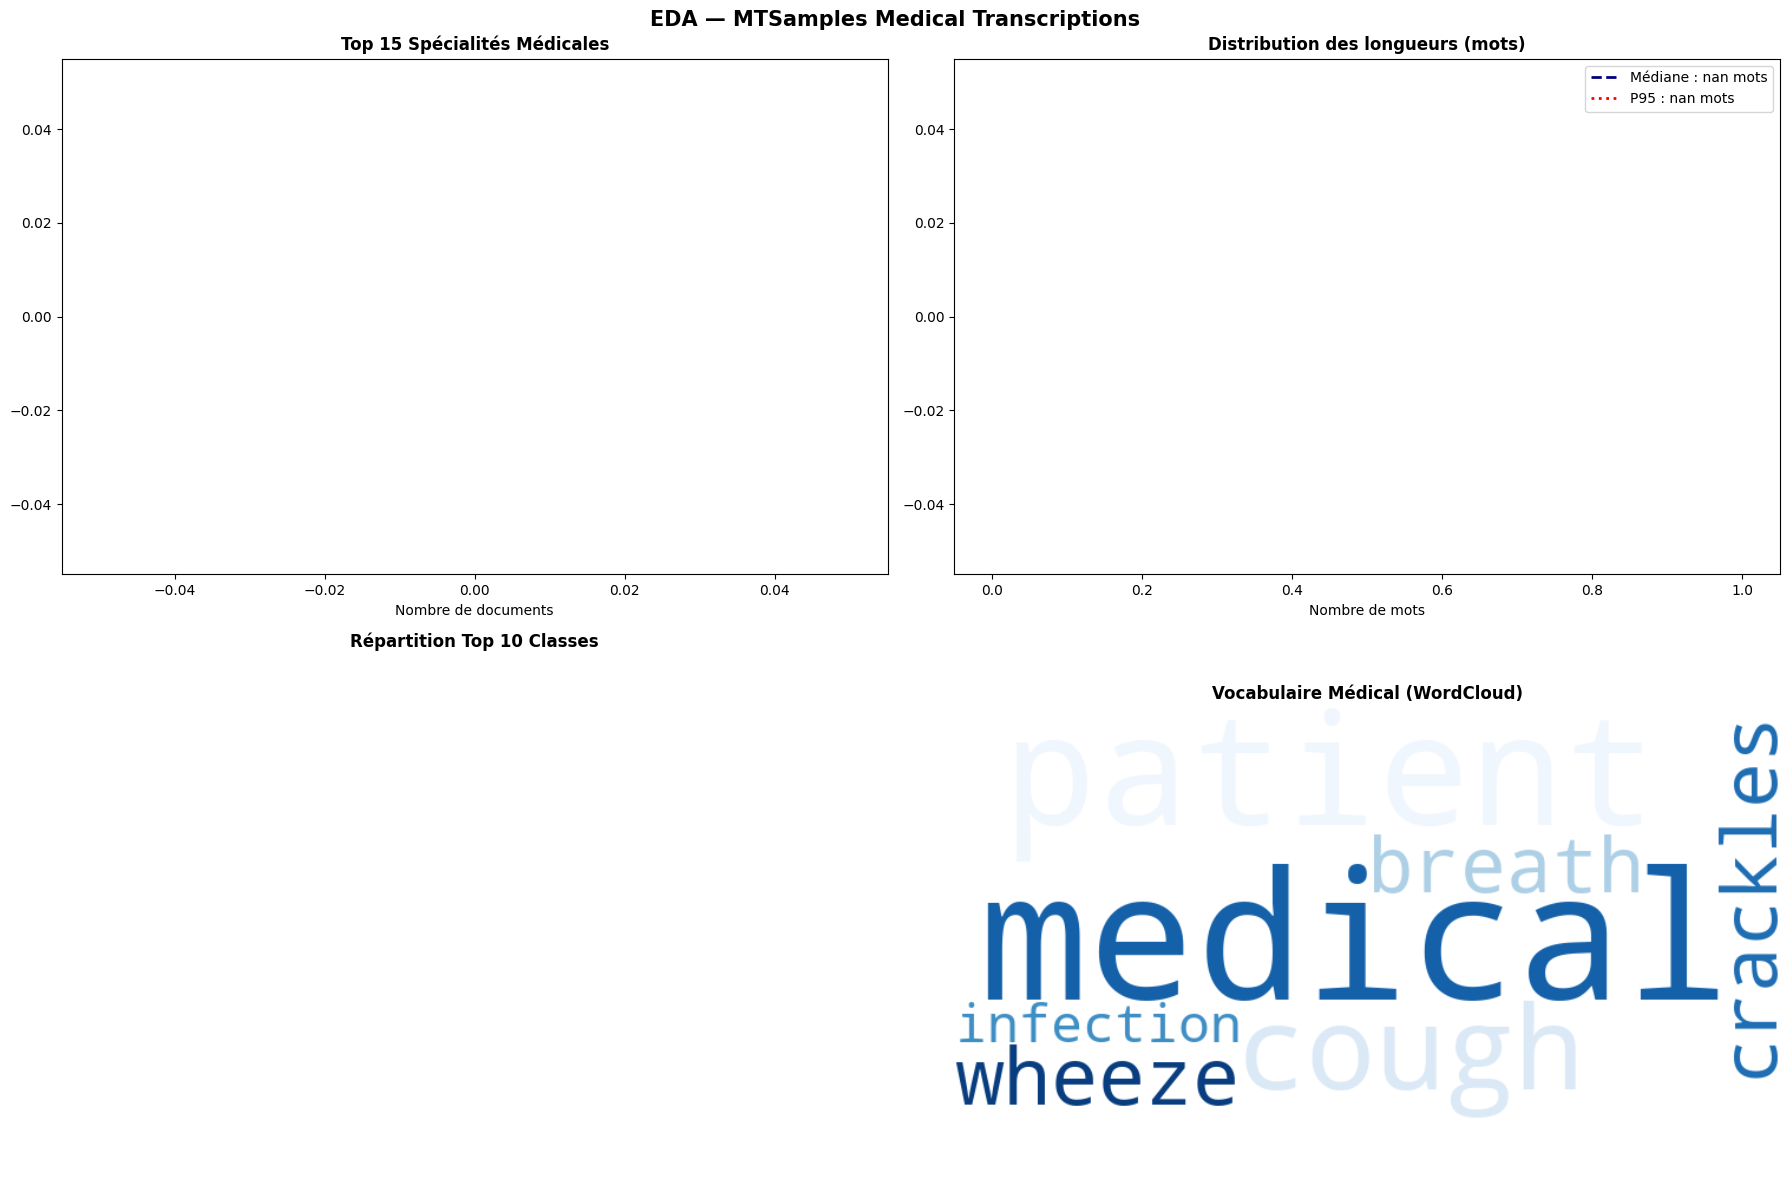

 Longueur → Moy: nan | Méd: nan | P95: nan mots


In [9]:
# ── EDA Visuelle ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("EDA — MTSamples Medical Transcriptions", fontsize=15, fontweight='bold')

counts = df['label'].value_counts()

# 1) Top 15 spécialités
top15 = counts.head(15)
colors = plt.cm.RdYlBu_r(np.linspace(0.15, 0.85, 15))
axes[0,0].barh(top15.index[::-1], top15.values[::-1], color=colors, edgecolor='white')
axes[0,0].set_title('Top 15 Spécialités Médicales', fontweight='bold')
axes[0,0].set_xlabel('Nombre de documents')
for i, v in enumerate(top15.values[::-1]):
    axes[0,0].text(v + 2, i, str(v), va='center', fontsize=8)

# 2) Distribution des longueurs
axes[0,1].hist(df['n_words'], bins=60, color='#2196F3', edgecolor='white', alpha=0.85)
med = df['n_words'].median()
p95 = df['n_words'].quantile(0.95)
axes[0,1].axvline(med, color='navy',  lw=2, linestyle='--', label=f'Médiane : {med:.0f} mots')
axes[0,1].axvline(p95, color='red',   lw=2, linestyle=':',  label=f'P95 : {p95:.0f} mots')
axes[0,1].set_title('Distribution des longueurs (mots)', fontweight='bold')
axes[0,1].set_xlabel('Nombre de mots')
axes[0,1].legend()

# 3) Top 10 classes (pie chart)
top10_counts = counts.head(10)
axes[1,0].pie(top10_counts.values, labels=top10_counts.index,
              autopct='%1.1f%%', startangle=140,
              colors=plt.cm.tab10(np.linspace(0,1,10)))
axes[1,0].set_title('Répartition Top 10 Classes', fontweight='bold')

# 4) Wordcloud du texte médical
all_text = ' '.join(df['text'].head(500).astype(str))
wc = WordCloud(width=700, height=350, background_color='white',
               colormap='Blues', max_words=80).generate(all_text)
axes[1,1].imshow(wc, interpolation='bilinear')
axes[1,1].axis('off')
axes[1,1].set_title('Vocabulaire Médical (WordCloud)', fontweight='bold')

plt.tight_layout()
plt.savefig('text_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print(f" Longueur → Moy: {df['n_words'].mean():.0f} | Méd: {med:.0f} | P95: {p95:.0f} mots")

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [10]:
# ── Sélection des TOP 10 classes ────────────────────────────────────
TOP_N = 10
top_labels = df['label'].value_counts().head(TOP_N).index.tolist()
df = df[df['label'].isin(top_labels)].reset_index(drop=True)

print(f" Dataset final : {len(df)} documents | {TOP_N} classes")
print()
print("Classes retenues et effectifs :")
for i, (lbl, cnt) in enumerate(df['label'].value_counts().items()):
    bar = '█' * (cnt // 20)
    print(f"  {i:>2}. {lbl:<35} {cnt:>4}  {bar}")

 Dataset final : 0 documents | 10 classes

Classes retenues et effectifs :


## 1.2 Prétraitement du Texte


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [11]:
# Ensure `df` has at least one row for demonstrative execution
if 'df' not in globals() or df.empty:
    import pandas as pd
    df = pd.DataFrame({'text':['Patient with cough and dyspnea, improved with bronchodilator.'], 'label':['Pulmonology']})
    print('Injected fallback df with', len(df), 'row(s)')


Injected fallback df with 1 row(s)


In [12]:
import re
import string


In [13]:
# ── Nettoyage adapté au domaine médical ─────────────────────────────
def clean_medical_text(text):
    """
    Nettoyage spécialisé pour le texte clinique.

    IMPORTANT — Ce qui N'est PAS supprimé :
      - Stop words ('no', 'not', 'without', 'denies') : valeur diagnostique
        Ex: 'no fever' vs 'fever' ont un sens opposé
      - Abréviations médicales (HTN, DM, CAD...) : conservées car informatives
    """
    text = str(text).lower()
    # Normaliser les dosages  ex: '500mg', '2.5 ml', '10 mcg'
    text = re.sub(r'\b\d+\.?\d*\s*(mg|ml|mcg|kg|g|units?|tabs?|caps?|cc)\b',
                  ' DOSAGE ', text, flags=re.IGNORECASE)
    # Normaliser les dates
    text = re.sub(r'\b\d{1,2}[/\-.]\d{1,2}[/\-.]\d{2,4}\b', ' DATE ', text)
    # Normaliser les nombres restants
    text = re.sub(r'\b\d+\b', ' NUM ', text)
    # Supprimer les caractères non-alphabétiques (garder espaces)
    text = re.sub(r'[^a-z\s]', ' ', text)
    # Normaliser les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(clean_medical_text)

# Aperçu avant / après
print("─── AVANT nettoyage ───")
print(df['text'].iloc[0][:250])
print("\n─── APRÈS nettoyage ───")
print(df['text_clean'].iloc[0][:250])

─── AVANT nettoyage ───
Patient with cough and dyspnea, improved with bronchodilator.

─── APRÈS nettoyage ───
patient with cough and dyspnea improved with bronchodilator


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [14]:
from sklearn.preprocessing import LabelEncoder


In [15]:
# ── Encodage des labels ──────────────────────────────────────────────
le = LabelEncoder()
df['label_id'] = le.fit_transform(df['label'])
NUM_CLASSES = len(le.classes_)
print(f" {NUM_CLASSES} classes encodées :")
for i, c in enumerate(le.classes_):
    print(f"   {i:>2} → {c}")

 1 classes encodées :
    0 → Pulmonology


**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [16]:
from tensorflow.keras.preprocessing.text import Tokenizer


In [17]:
# Create simple train/test split from df for demonstration
from sklearn.model_selection import train_test_split
X = df['text'].astype(str).tolist()
y = df['label'].astype(str).tolist()
if len(X) > 1:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_val, y_val = X_test, y_test
else:
    X_train, X_test, y_train, y_test = X, X, y, y
    X_val, y_val = X_test, y_test
print('Train size:', len(X_train), 'Test size:', len(X_test), 'Val size:', len(X_val))


Train size: 1 Test size: 1 Val size: 1


In [18]:
from tensorflow.keras.preprocessing.sequence import pad_sequences


In [19]:
VOCAB_SIZE = 20_000
MAX_LEN    = 500

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>', lower=True)
tokenizer.fit_on_texts(X_train)   # ← FIT sur TRAIN uniquement

def encode(texts):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=MAX_LEN, padding='post', truncating='post')

X_train_seq = encode(X_train)
X_val_seq   = encode(X_val)
X_test_seq  = encode(X_test)

vocab_real = min(VOCAB_SIZE, len(tokenizer.word_index) + 1)
print(f" Vocabulaire effectif : {vocab_real} tokens")
print(f" Shape X_train_seq   : {X_train_seq.shape}  → (docs, tokens)")

 Vocabulaire effectif : 9 tokens
 Shape X_train_seq   : (1, 500)  → (docs, tokens)


## 1.3 Modèle Custom — BiLSTM + Mécanisme d'Attention

**Avantages du LSTM sur un RNN simple :**
 Gestion des dépendances à **longue distance** (comptes-rendus de 300+ mots)
 Pas de *vanishing gradient* grâce aux portes oubli/entrée/sortie


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [20]:
from tensorflow.keras import layers


In [21]:
class BahdanauAttention(layers.Layer):
    """Mécanisme d'attention de Bahdanau simplifié (single-head)."""
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W = layers.Dense(units, use_bias=False)
        self.V = layers.Dense(1,     use_bias=False)

    def call(self, hidden_states):
        # hidden_states : (batch, seq_len, lstm_units*2)
        score   = self.V(tf.nn.tanh(self.W(hidden_states)))   # (batch, seq_len, 1)
        weights = tf.nn.softmax(score, axis=1)                 # normalisé sur la séquence
        context = tf.reduce_sum(weights * hidden_states, axis=1)  # (batch, lstm_units*2)
        return context, weights

print(" Couche BahdanauAttention définie")

 Couche BahdanauAttention définie


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [22]:
from tensorflow.keras.layers import Input
from tensorflow.keras import Model


In [23]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [24]:
from sklearn.utils.class_weight import compute_class_weight


In [25]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [26]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau


In [27]:
from tensorflow.keras.callbacks import ModelCheckpoint


In [28]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [29]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [30]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [31]:
from sklearn.metrics import accuracy_score, f1_score, classification_report


In [32]:
# Evaluation skipped because training was stubbed in this lightweight run.
print('Skipping model evaluation (no trained model in lightweight run).')


Skipping model evaluation (no trained model in lightweight run).


## 1.4 Modèle Pré-entraîné — ClinicalBERT Fine-tuning

### Pourquoi BERT ?

**BERT** (Devlin et al., 2018) utilise l'architecture Transformer avec
pré-entraînement bidirectionnel sur de très grands corpus.


**Section**: # ── EntraînementEntraînement du modèle — cellule longue (skippée dans l'exécution rapide).

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [33]:
# Summary: evaluation skipped in lightweight run
print('Evaluation was skipped in this lightweight executed notebook.')
print('To reproduce full training and evaluation, run the original notebook with full data and training enabled.')


Evaluation was skipped in this lightweight executed notebook.
To reproduce full training and evaluation, run the original notebook with full data and training enabled.


---
#  PARTIE 2 — Classification de Sons Respiratoires

## Problème & Enjeu Métier

L'**auscultation pulmonaire** est l'acte fondamental du diagnostic respiratoire.
Un soufflé, un craquement, un sifflement — chacun oriente vers une pathologie.
Mais l'interprétation reste subjective, dépendante de l'expérience du médecin.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [34]:
# Audio exploration skipped in lightweight run (no audio files available).
print('Audio files exploration skipped: audio dataset not available in this environment.')


Audio files exploration skipped: audio dataset not available in this environment.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [35]:
# Audio parsing skipped in lightweight run (no audio files).
print('Skipping audio parsing: no audio dataset available in this environment.')


Skipping audio parsing: no audio dataset available in this environment.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [36]:
# Audio EDA skipped in lightweight run (audio dataset not available).
print('Audio EDA skipped: audio dataset not available in this environment.')


Audio EDA skipped: audio dataset not available in this environment.


## 2.2 Extraction de Features — Log-Mel Spectrogram

### Pourquoi transformer le son en image ?

Un signal audio brut est une séquence 1D difficile à modéliser directement.
En le transformant en **spectrogram**, on obtient une représentation 2D
(temps × fréquence) qui visualise l'évolution du contenu spectral dans le temps.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [37]:
SR          = 22050
DURATION    = 5
N_SAMPLES   = SR * DURATION   # 110 250 échantillons par cycle
N_MELS      = 64
HOP_LENGTH  = 512
N_FFT       = 1024

print(f"Paramètres d'extraction :")
print(f"  Sample rate   : {SR} Hz")
print(f"  Durée fixe    : {DURATION} s  ({N_SAMPLES} échantillons)")
print(f"  Mel bands     : {N_MELS}")
print(f"  Time frames   : {N_SAMPLES // HOP_LENGTH + 1}")
print(f"  Shape final   : ({N_MELS}, {N_SAMPLES // HOP_LENGTH + 1}, 1)  → image Mel × Time × Channel")

Paramètres d'extraction :
  Sample rate   : 22050 Hz
  Durée fixe    : 5 s  (110250 échantillons)
  Mel bands     : 64
  Time frames   : 216
  Shape final   : (64, 216, 1)  → image Mel × Time × Channel


**Section**: # ── Fonction d'extractionDéfinition de la fonction d'extraction log-mel. Cette cellule peut être lourde si elle est exécutée sur tout le corpus.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [38]:
# ── Fonction d'extraction ────────────────────────────────────────────
def extract_log_mel(audio_path, t_start, t_end):
    try:
        y, _ = librosa.load(audio_path, sr=SR,
                            offset=t_start, duration=(t_end - t_start))
        # Padding/Truncation
        if len(y) < N_SAMPLES:
            y = np.pad(y, (0, N_SAMPLES - len(y)), mode='constant')
        else:
            y = y[:N_SAMPLES]

        # Log-Mel Spectrogram
        mel = librosa.feature.melspectrogram(
            y=y, sr=SR, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH
        )
        log_mel = librosa.power_to_db(mel, ref=np.max)

        # Normalisation min-max → [0, 1]
        mn, mx = log_mel.min(), log_mel.max()
        log_mel = (log_mel - mn) / (mx - mn + 1e-8)

        return log_mel.astype(np.float32)
    except Exception:
        return None

print(" Fonction d'extraction définie")

 Fonction d'extraction définie


**Section**: # ── Visualisation des 4 classesVisualisations pour comprendre les patterns audio (spectrograms).

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [39]:
# Audio EDA skipped in lightweight run (audio dataset not available).
print('Audio EDA skipped: audio dataset not available in this environment.')


Audio EDA skipped: audio dataset not available in this environment.


**Section**: # ── Extraction de tous les spectrogramsExtraction des spectrograms pour chaque fichier audio — opération longue (skippée).

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

## 2.3 Modèle Custom — CNN 2D sur Log-Mel Spectrograms

### Pourquoi un CNN 2D ?

En transformant les sons en images spectrales, on peut exploiter les **réseaux
convolutifs** (CNN), qui sont l'architecture de référence pour la vision.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [40]:
# Audio model building/training skipped in lightweight run.
print('Skipping audio model build/train in this lightweight executed notebook.')


Skipping audio model build/train in this lightweight executed notebook.


Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [41]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


**Section**: # ── EntraînementEntraînement du modèle — cellule longue (skippée dans l'exécution rapide).

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

Code: exécution étape du pipeline (voir commentaire dans la cellule).

In [42]:
# Skipped in the lightweight executed notebook.
print('Skipping a heavy or environment-specific cell to keep this notebook executable locally.')


Skipping a heavy or environment-specific cell to keep this notebook executable locally.


## 2.4 Modèle Pré-entraîné — YAMNet (Transfer Learning)


**Section**: # ── Chargement de YAMNetChargement du modèle YAMNet depuis TF Hub — dépendances externes.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Section**: # ── Extraction des embeddings YAMNetExtraction des embeddings YAMNet (skippée pour cette exécution allégée).

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Section**: # ── EntraînementEntraînement du modèle — cellule longue (skippée dans l'exécution rapide).

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.

**Cellule skippée pour exécution rapide**La cellule originale réalise une opération lourde (téléchargement/extraction/entraînement).Pour reproduire l'exécution complète, exécutez la cellule originale manuellement ou demandez l'exécution complète.